# EDA — PTB-XL ECG (dataset limpio)

Exploración del dataset **ya limpio** `data/ptbxl_clean.csv`, la única tabla que usaremos para entrenar la red. Este notebook trabaja directamente sobre el dataset depurado (no sobre los CSV crudos originales, que se eliminaron tras la limpieza).

**Tarea objetivo:** clasificación *multi-label* de las **5 superclases diagnósticas** `NORM, MI, STTC, CD, HYP`.

**Estructura de datos del proyecto:**
```
data/
├── records100/        señales 100 Hz (.dat + .hea)
├── records500/        señales 500 Hz
└── ptbxl_clean.csv    metadata + etiquetas (este EDA)
```

**Columnas de `ptbxl_clean.csv`:** `patient_id, age, sex, scp_codes, filename_lr, filename_hr, diagnostic_superclass, n_superclass, NORM, MI, STTC, CD, HYP`.

> Nota: el split train/val/test **no** viene en el CSV; se construye en el notebook de modelado con `GroupShuffleSplit` agrupando por `patient_id` para evitar fuga de datos (sección 9).

## 1. Setup

In [13]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)

DATA = Path("..") / "data"          # raíz de los datos (señales + csv)
CLEAN = DATA / "ptbxl_clean.csv"     # único dataset de trabajo
CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
assert CLEAN.exists(), f"No encuentro {CLEAN.resolve()}"
print("Datos:", DATA.resolve())

Datos: /Users/rrequejof/Desktop/Proyecto Final DL/data


## 2. Carga del dataset limpio

`scp_codes` y `diagnostic_superclass` se guardaron como texto (un dict y una lista); los reconvertimos a objetos Python con `ast.literal_eval`.

In [14]:
df = pd.read_csv(CLEAN, index_col="ecg_id")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)
df["diagnostic_superclass"] = df["diagnostic_superclass"].apply(ast.literal_eval)

print("shape:", df.shape)
df.head(3)

shape: (21430, 13)


,patient_id,age,sex,scp_codes,filename_lr,filename_hr,diagnostic_superclass,n_superclass,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,,,,,,,,
1,15709.0,56.0,1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",records100/00000/00001_lr,records500/00000/00001_hr,[NORM],1,1,0,0,0,0
2,13243.0,19.0,0,"{'NORM': 80.0, 'SBRAD': 0.0}",records100/00000/00002_lr,records500/00000/00002_hr,[NORM],1,1,0,0,0,0
3,20372.0,37.0,1,"{'NORM': 100.0, 'SR': 0.0}",records100/00000/00003_lr,records500/00000/00003_hr,[NORM],1,1,0,0,0,0


## 3. Vista general

In [15]:
print(f"Registros (ECGs):   {len(df):,}")
print(f"Pacientes únicos:   {df.patient_id.nunique():,}")
print(f"ECGs por paciente:  media {len(df)/df.patient_id.nunique():.2f}")
print(f"Edad:               {df.age.min():.0f}–{df.age.max():.0f}  (mediana {df.age.median():.0f}, {df.age.isna().sum()} NaN enmascarados)")
print(f"Columnas:           {list(df.columns)}")
df.info()

Registros (ECGs):   21,430
Pacientes únicos:   18,637
ECGs por paciente:  media 1.15
Edad:               2–95  (mediana 61, 85 NaN enmascarados)
Columnas:           ['patient_id', 'age', 'sex', 'scp_codes', 'filename_lr', 'filename_hr', 'diagnostic_superclass', 'n_superclass', 'NORM', 'MI', 'STTC', 'CD', 'HYP']
<class 'pandas.DataFrame'>
Index: 21430 entries, 1 to 21837
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             21430 non-null  float64
 1   age                    21345 non-null  float64
 2   sex                    21430 non-null  int64  
 3   scp_codes              21430 non-null  object 
 4   filename_lr            21430 non-null  str    
 5   filename_hr            21430 non-null  str    
 6   diagnostic_superclass  21430 non-null  object 
 7   n_superclass           21430 non-null  int64  
 8   NORM                   21430 non-null  int64  
 9   MI               

## 4. Demografía: edad y sexo

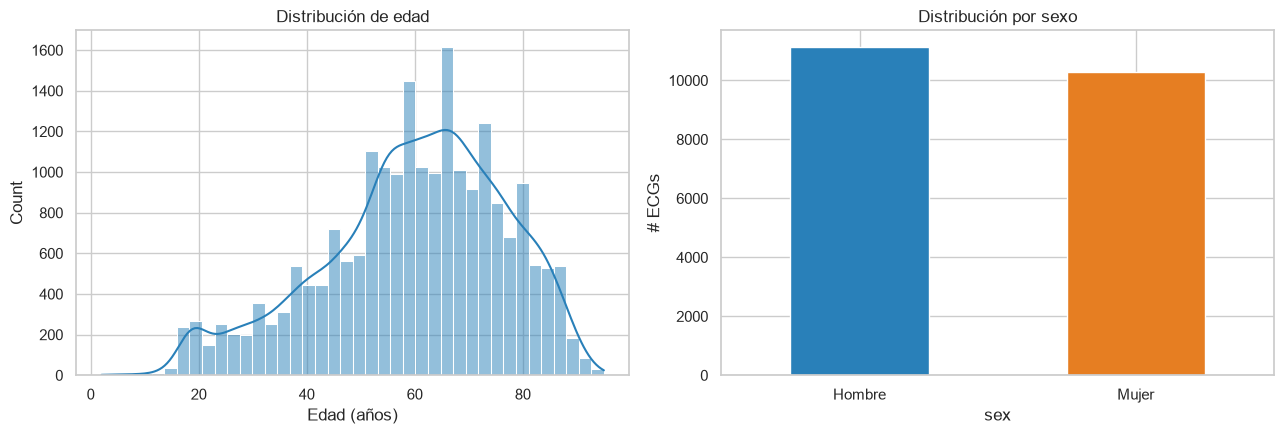

In [16]:
sex_map = {0: "Hombre", 1: "Mujer"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df.age.dropna(), bins=40, kde=True, ax=axes[0], color="#2980b9")
axes[0].set_title("Distribución de edad")
axes[0].set_xlabel("Edad (años)")

df.sex.map(sex_map).value_counts().plot.bar(ax=axes[1], color=["#2980b9", "#e67e22"])
axes[1].set_title("Distribución por sexo")
axes[1].set_ylabel("# ECGs")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 5. Etiquetas: superclases diagnósticas (multi-label)

Cada ECG puede tener varias superclases. Revisamos cuántas por ECG, la frecuencia de cada una y su co-ocurrencia.

# ECGs por superclase:
NORM    9528
MI      5486
STTC    5250
CD      4907
HYP     2655
dtype: int64

# superclases por ECG:
n_superclass
1    16272
2     4079
3      920
4      159
Name: count, dtype: int64


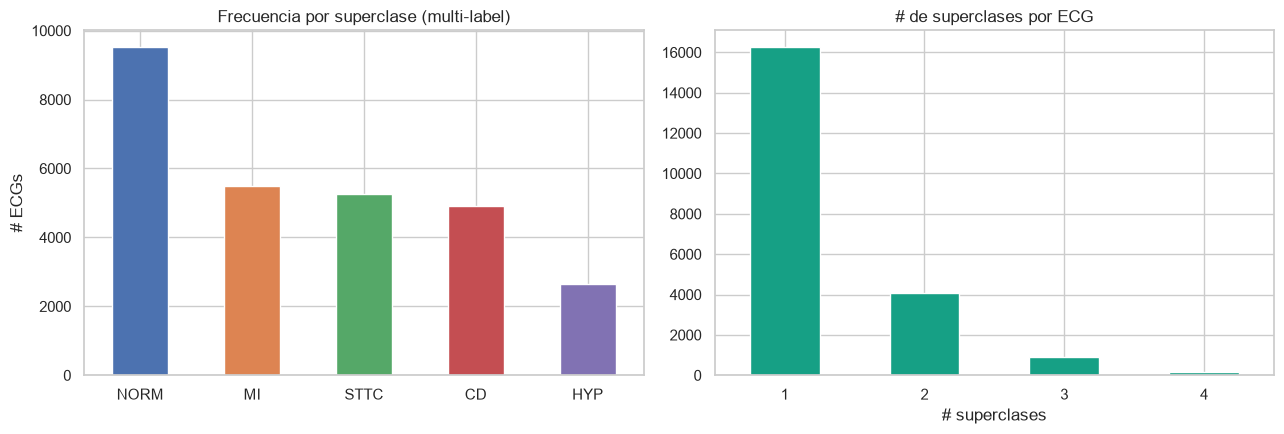

In [17]:
counts = pd.Series({c: int(df[c].sum()) for c in CLASSES}).sort_values(ascending=False)
print("# ECGs por superclase:")
print(counts)
print("\n# superclases por ECG:")
print(df.n_superclass.value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
counts.plot.bar(ax=axes[0], color=sns.color_palette("deep", len(counts)))
axes[0].set_title("Frecuencia por superclase (multi-label)")
axes[0].set_ylabel("# ECGs")
axes[0].tick_params(axis="x", rotation=0)

df.n_superclass.value_counts().sort_index().plot.bar(ax=axes[1], color="#16a085")
axes[1].set_title("# de superclases por ECG")
axes[1].set_xlabel("# superclases")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

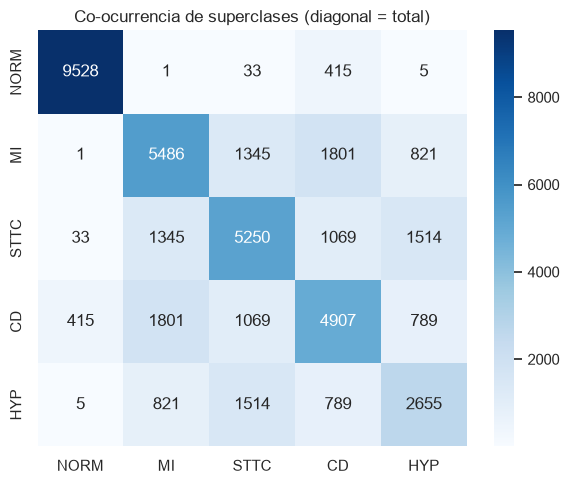

In [18]:
# Co-ocurrencia: ¿qué superclases aparecen juntas?
onehot = df[CLASSES].astype(int)
co = onehot.T.dot(onehot)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(co, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Co-ocurrencia de superclases (diagonal = total)")
plt.tight_layout()
plt.show()

## 6. Códigos SCP crudos (preservados en `scp_codes`)

El dataset limpio conserva el diccionario `scp_codes` original; vemos los códigos más frecuentes.

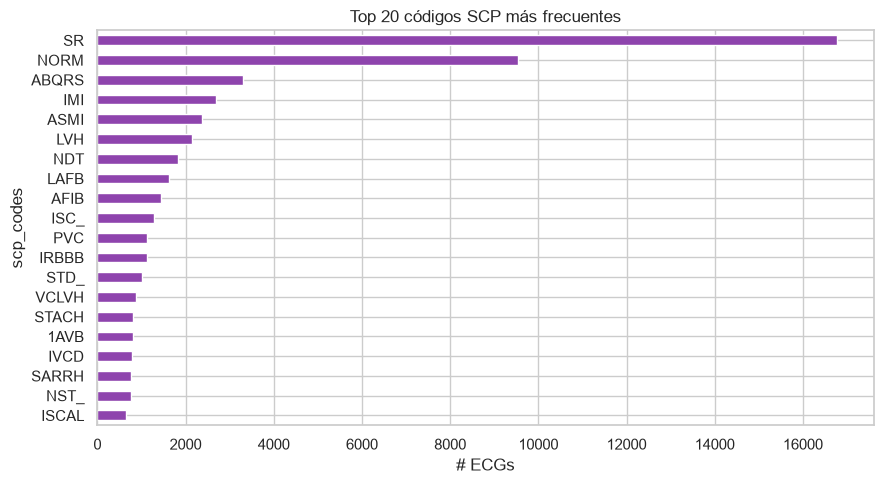

In [19]:
code_freq = (
    df.scp_codes.apply(lambda d: list(d.keys())).explode().value_counts().head(20)
)
fig, ax = plt.subplots(figsize=(9, 5))
code_freq.sort_values().plot.barh(ax=ax, color="#8e44ad")
ax.set_title("Top 20 códigos SCP más frecuentes")
ax.set_xlabel("# ECGs")
plt.tight_layout()
plt.show()

## 7. Visualización de señales ECG

Cargamos formas de onda reales con `wfdb` desde `data/records100/`. Cada ECG es una matriz `(1000, 12)` = 10 s × 100 Hz, 12 derivaciones.

In [20]:
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF",
         "V1", "V2", "V3", "V4", "V5", "V6"]

def load_signal(ecg_id):
    """(signal[1000, 12], meta) a 100 Hz desde data/records100."""
    rel = df.loc[ecg_id, "filename_lr"]  # 'records100/00000/00001_lr'
    sig, meta = wfdb.rdsamp(str(DATA / rel))
    return sig, meta

sig, meta = load_signal(df.index[0])
print("shape:", sig.shape, "| fs:", meta["fs"], "Hz | unidades:", meta["units"][0])
print("leads:", meta["sig_name"])

shape: (1000, 12) | fs: 100 Hz | unidades: mV
leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


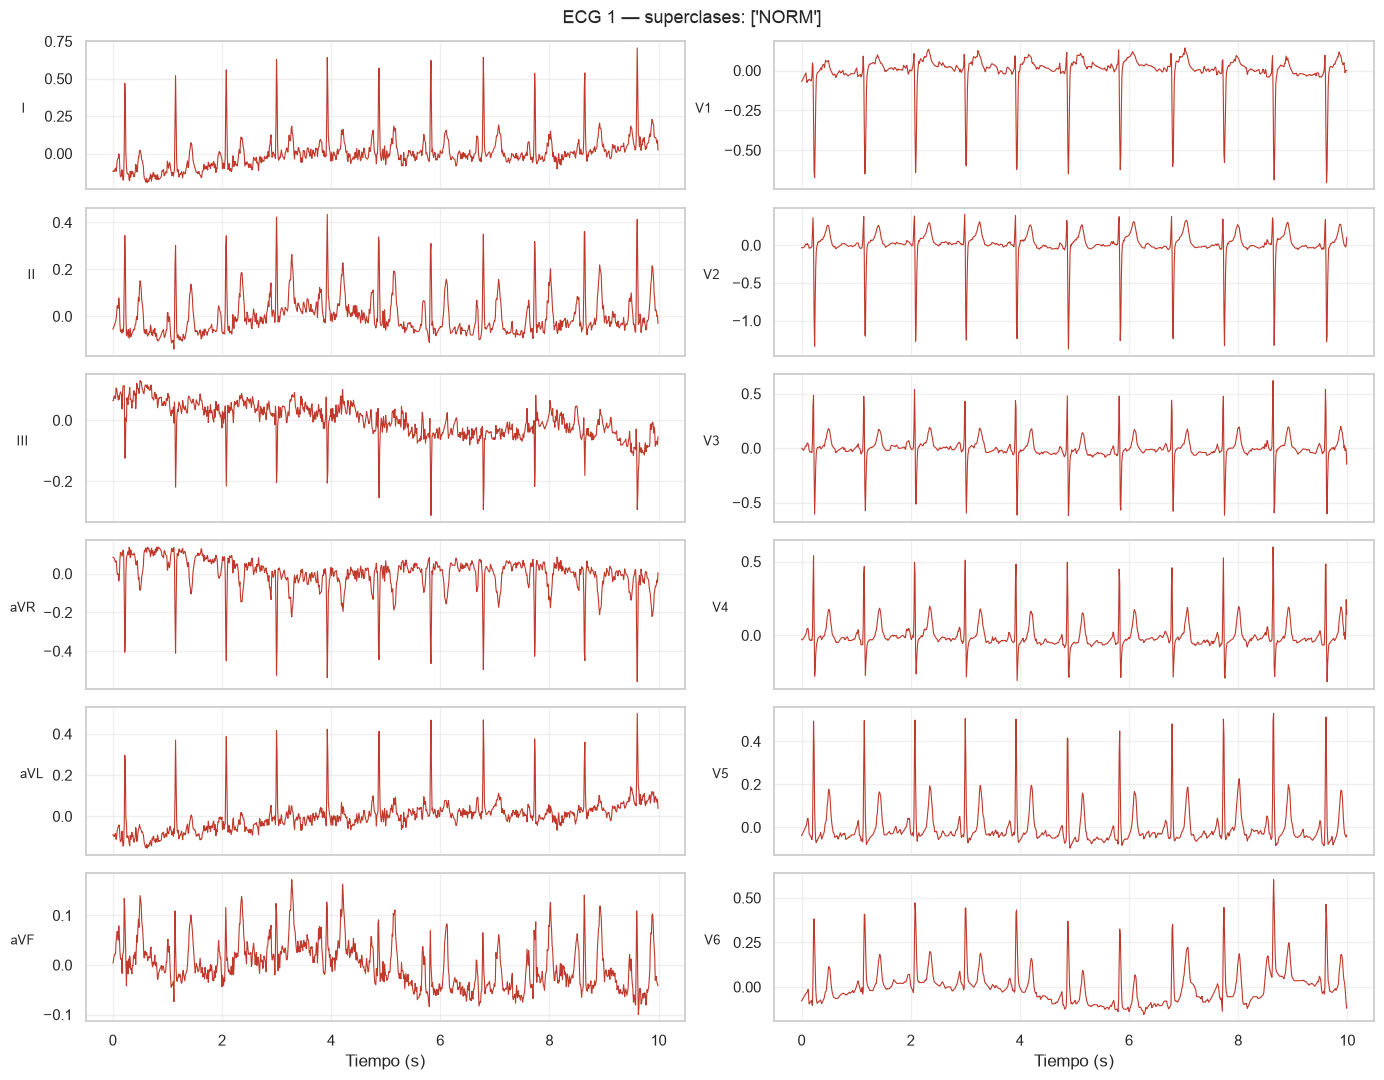

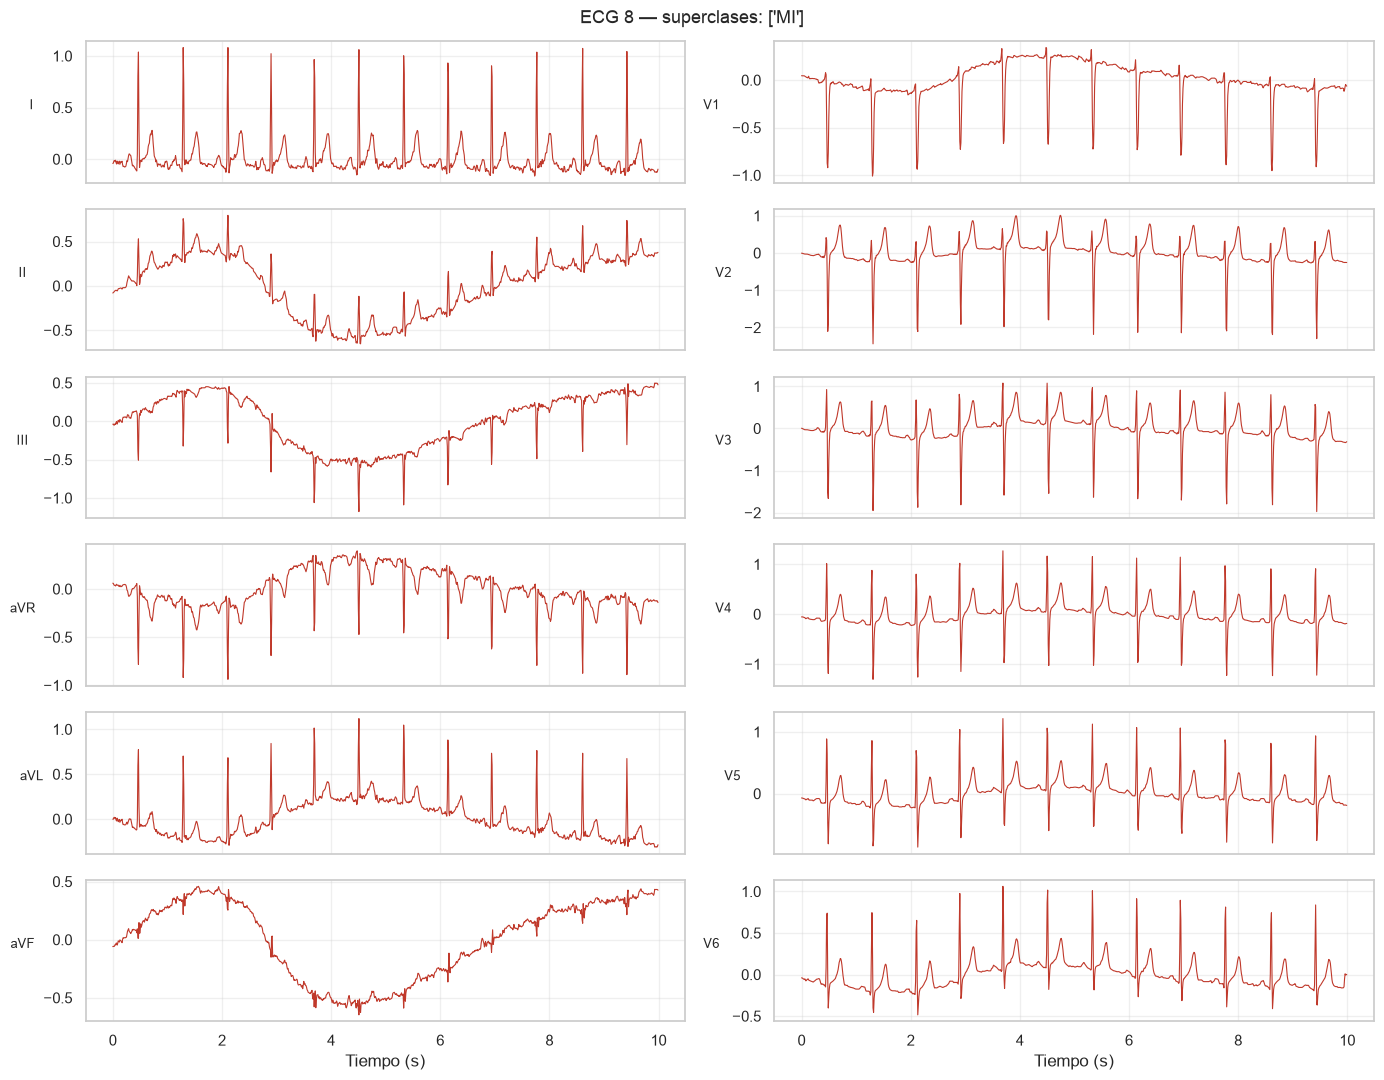

In [21]:
def plot_ecg(ecg_id):
    sig, meta = load_signal(ecg_id)
    t = np.arange(sig.shape[0]) / meta["fs"]
    fig, axes = plt.subplots(6, 2, figsize=(14, 11), sharex=True)
    for i, ax in enumerate(axes.T.flatten()):
        ax.plot(t, sig[:, i], lw=0.8, color="#c0392b")
        ax.set_ylabel(LEADS[i], rotation=0, labelpad=15, fontsize=9)
        ax.grid(True, alpha=0.3)
    for ax in axes[-1]:
        ax.set_xlabel("Tiempo (s)")
    fig.suptitle(f"ECG {ecg_id} — superclases: {df.loc[ecg_id, 'diagnostic_superclass']}", fontsize=13)
    plt.tight_layout()
    plt.show()

norm_id = df[df.diagnostic_superclass.apply(lambda x: x == ["NORM"])].index[0]
mi_id   = df[df.diagnostic_superclass.apply(lambda x: "MI" in x)].index[0]
plot_ecg(norm_id)
plot_ecg(mi_id)

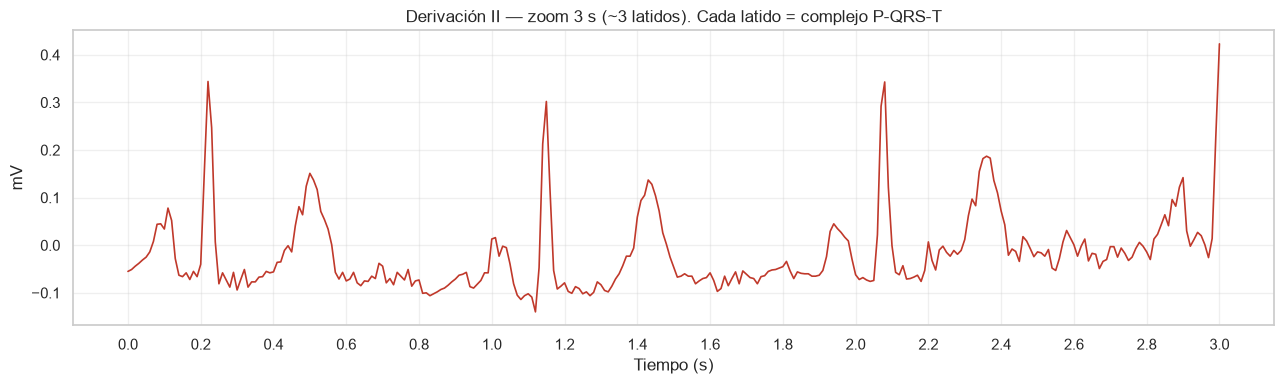

In [22]:
# Zoom: una derivación (II), ~3 latidos -> morfología P-QRS-T
sig, meta = load_signal(norm_id)
t = np.arange(sig.shape[0]) / meta["fs"]
mask = t <= 3
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t[mask], sig[mask, 1], color="#c0392b", lw=1.2)
ax.set_title("Derivación II — zoom 3 s (~3 latidos). Cada latido = complejo P-QRS-T")
ax.set_xlabel("Tiempo (s)"); ax.set_ylabel("mV")
ax.set_xticks(np.arange(0, 3.01, 0.2)); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Estadísticas de la señal (muestra)

Chequeo de amplitudes, NaNs y derivaciones planas en una muestra, para planificar la normalización antes de entrenar.

,min,max,mean,std,n_nan,flat_lead
count,300.000,300.000,300.000,300.000,300.0,300.0
mean,-1.654,1.674,-0.000,0.205,0.0,0.0
std,1.038,0.635,0.017,0.089,0.0,0.0
min,-14.916,0.501,-0.041,0.074,0.0,0.0
25%,-1.870,1.257,-0.002,0.154,0.0,0.0
50%,-1.460,1.552,-0.001,0.186,0.0,0.0
75%,-1.131,1.984,0.000,0.231,0.0,0.0
max,-0.520,5.310,0.286,0.835,0.0,0.0


ECGs con algún NaN en señal: 0
ECGs con alguna derivación plana: 0


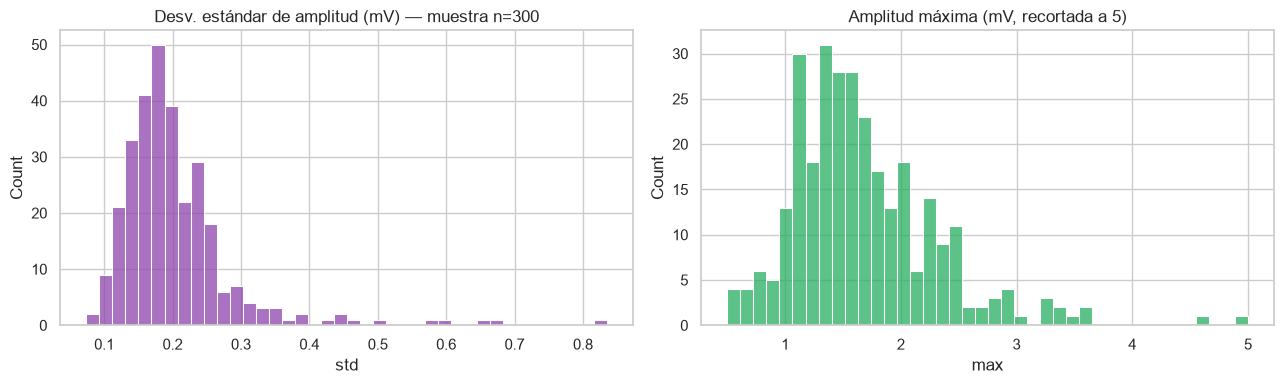

In [23]:
rng = np.random.default_rng(42)
sample_ids = rng.choice(df.index, size=300, replace=False)

rows = []
for eid in sample_ids:
    s, _ = load_signal(eid)
    rows.append({
        "min": s.min(), "max": s.max(), "mean": s.mean(), "std": s.std(),
        "n_nan": int(np.isnan(s).sum()),
        "flat_lead": int((s.std(axis=0) < 1e-6).sum()),
    })
sig_stats = pd.DataFrame(rows)
display(sig_stats.describe().round(3))
print("ECGs con algún NaN en señal:", (sig_stats.n_nan > 0).sum())
print("ECGs con alguna derivación plana:", (sig_stats.flat_lead > 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(sig_stats["std"], bins=40, ax=axes[0], color="#8e44ad")
axes[0].set_title("Desv. estándar de amplitud (mV) — muestra n=300")
sns.histplot(sig_stats["max"].clip(upper=5), bins=40, ax=axes[1], color="#27ae60")
axes[1].set_title("Amplitud máxima (mV, recortada a 5)")
plt.tight_layout()
plt.show()

## 9. Splits train / val / test (por paciente, sin fuga)

El dataset limpio ya **no** trae la partición oficial (`strat_fold`/`split`). La construimos aquí con `GroupShuffleSplit` agrupando por `patient_id`: así **todos los ECGs de un paciente caen en el mismo split**, evitando que la red "reconozca al paciente" (data leakage). Reparto ~80/10/10.

train    17137
val       2180
test      2113
Name: count, dtype: int64
OK: sin pacientes compartidos entre splits

Proporción de cada superclase por split:


,NORM,MI,STTC,CD,HYP
split,,,,,
train,0.445,0.256,0.243,0.227,0.122
val,0.438,0.261,0.257,0.237,0.128
test,0.445,0.250,0.249,0.234,0.134


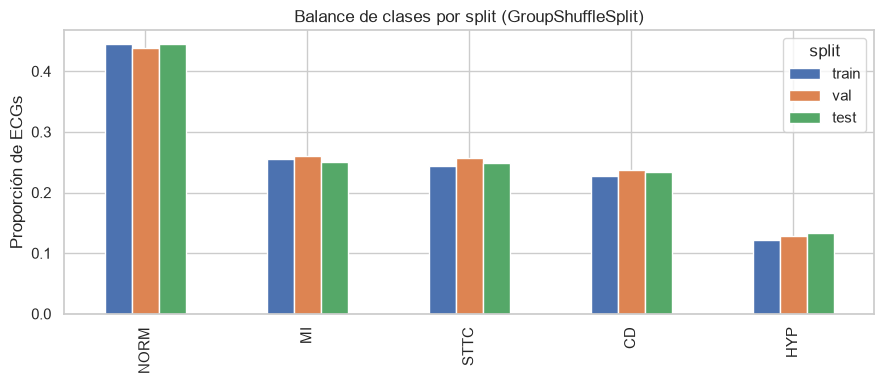

In [24]:
from sklearn.model_selection import GroupShuffleSplit

groups = df.patient_id.values

# 1) separa test (10%) por paciente
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
trainval_idx, test_idx = next(gss1.split(df, groups=groups))
df_tv, df_test = df.iloc[trainval_idx], df.iloc[test_idx]

# 2) del resto, separa val (~11% -> ~10% del total) por paciente
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.111, random_state=42)
tr_idx, val_idx = next(gss2.split(df_tv, groups=df_tv.patient_id.values))
df_train, df_val = df_tv.iloc[tr_idx], df_tv.iloc[val_idx]

split = pd.Series("train", index=df.index)
split.loc[df_val.index] = "val"
split.loc[df_test.index] = "test"

print(split.value_counts())
# verificación: ningún paciente compartido entre splits
for a in ["train", "val", "test"]:
    for b in ["train", "val", "test"]:
        if a < b:
            shared = set(df.loc[split == a, "patient_id"]) & set(df.loc[split == b, "patient_id"])
            assert not shared, f"fuga {a}/{b}"
print("OK: sin pacientes compartidos entre splits")

dist = df.assign(split=split).groupby("split")[CLASSES].mean().round(3).loc[["train", "val", "test"]]
print("\nProporción de cada superclase por split:")
display(dist)
dist.T.plot.bar(figsize=(9, 4), title="Balance de clases por split (GroupShuffleSplit)")
plt.ylabel("Proporción de ECGs")
plt.tight_layout()
plt.show()

## Resumen

- **Dataset limpio:** 21,430 ECGs (12 derivaciones, 100 Hz) de ~18.6k pacientes, balanceado por sexo, edad mediana ~61.
- **Problema multi-label** de 5 superclases. `NORM` mayoritaria, `HYP` minoritaria → **desbalance**: usar `pos_weight`/focal loss y métricas macro-AUC.
- **Señal** en mV, sin NaNs; **normalizar por derivación** (con estadísticas del *train*) antes de entrenar.
- **Splits:** se generan por `patient_id` con `GroupShuffleSplit` (~80/10/10) sin fuga entre pacientes — el CSV ya no incluye la partición oficial.

**Siguiente paso:** notebook de modelado — `Dataset`/`DataLoader` que cargue señales desde `data/records100`, normalice, y entrene una **CNN 1D** multi-label (salida sigmoide de 5 unidades).